# Lizard Image Classification Pipeline

This notebook follows a structured data science workflow for a TensorFlow/Keras lizard image classification project. The dataset is assumed to use a Kaggle-style image classification layout with `train/`, `test/`, `train.csv`, `test.csv`, and `sample_submission.csv`.

## 1. Project Setup

This section contains imports, project paths, constants, and random seeds. Keeping this setup in one place makes the notebook easier to reproduce and debug.

In [1]:
# Optional installation cell. Uncomment if needed.
# %pip install -q tensorflow pandas numpy matplotlib seaborn scikit-learn pillow
# %pip install -q fiftyone cleanvision cleanlab optuna tensorboard openpyxl

In [2]:
from pathlib import Path
import os
import random
import shutil
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from PIL import Image, ImageFile, UnidentifiedImageError
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, confusion_matrix, f1_score

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

warnings.filterwarnings("ignore")
ImageFile.LOAD_TRUNCATED_IMAGES = True

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.keras.utils.set_random_seed(SEED)

print("TensorFlow:", tf.__version__)
print("GPU devices:", tf.config.list_physical_devices("GPU"))


TensorFlow: 2.21.0
GPU devices: []


In [ ]:
# Paths
ROOT = Path.cwd()
TRAIN_DIR = ROOT / "train"
TEST_DIR = ROOT / "test"
TRAIN_CSV = ROOT / "train.csv"
TEST_CSV = ROOT / "test.csv"
SAMPLE_SUBMISSION = ROOT / "sample_submission.csv"

ARTIFACTS_DIR = ROOT / "artifacts"
REPORT_DIR = ARTIFACTS_DIR / "reports"

for directory in [ARTIFACTS_DIR, REPORT_DIR]:
    directory.mkdir(parents=True, exist_ok=True)

IMG_SIZE = (224, 224)
BATCH_SIZE = 32
AUTOTUNE = tf.data.AUTOTUNE

PRIMARY_METRIC = "macro_f1"
INFERENCE_SEARCH_MODE = "auto"
KNN_NEIGHBORS = [1, 3, 5, 7, 9, 11, 13, 15, 21, 31]
KNN_TEMPERATURES = [0.03, 0.05, 0.07, 0.10, 0.15, 0.20, 0.30]
BLEND_ALPHAS = np.linspace(0.0, 1.0, 51)

HAS_GPU = len(tf.config.list_physical_devices("GPU")) > 0
CPU_OPTUNA_MODE = not HAS_GPU
RUN_OPTUNA = True

# CPU mode keeps Optuna useful without retraining/fine-tuning a CNN for hours.
# The expensive full TTA + kNN/blend search still runs once after final training.
N_OPTUNA_TRIALS = 6 if CPU_OPTUNA_MODE else 25
OPTUNA_HEAD_MAX_EPOCHS = 15
FINAL_HEAD_MAX_EPOCHS = 15
OPTUNA_SEARCH_FINE_TUNING = HAS_GPU
OPTUNA_FINE_TUNE_MAX_EPOCHS = 0 if CPU_OPTUNA_MODE else 8
OPTUNA_PRUNING_WARMUP_EPOCHS = 4 if CPU_OPTUNA_MODE else 4
OPTUNA_HYPERBAND_MIN_RESOURCE = 5
OPTUNA_HYPERBAND_MAX_RESOURCE = OPTUNA_HEAD_MAX_EPOCHS + OPTUNA_FINE_TUNE_MAX_EPOCHS
OPTUNA_HYPERBAND_REDUCTION_FACTOR = 3
OPTUNA_BATCH_CHOICES = [32] if CPU_OPTUNA_MODE else [16, 24, 32]
OPTUNA_DENSE_CHOICES = [0, 128, 256] if CPU_OPTUNA_MODE else [0, 128, 256, 512]
OPTUNA_INFERENCE_FAMILIES = ["softmax", "softmax_tta"] if CPU_OPTUNA_MODE else ["softmax", "softmax_tta", "knn", "blend"]
OPTUNA_EMBEDDING_VARIANTS = ["orig", "flip_avg"] if CPU_OPTUNA_MODE else ["orig", "flip_only", "flip_avg"]
OPTUNA_KNN_NEIGHBORS = [7, 15, 31] if CPU_OPTUNA_MODE else KNN_NEIGHBORS
OPTUNA_KNN_TEMPERATURES = [0.10, 0.15, 0.20] if CPU_OPTUNA_MODE else KNN_TEMPERATURES

print("CPU Optuna mode:", CPU_OPTUNA_MODE)
print("Optuna trials:", N_OPTUNA_TRIALS)
print("Optuna fine-tuning search:", OPTUNA_SEARCH_FINE_TUNING)

assert TRAIN_DIR.exists(), f"Missing training directory: {TRAIN_DIR}"
assert TEST_DIR.exists(), f"Missing test directory: {TEST_DIR}"


## 2. Dataset Loading

We read the dataset folders, determine class names from the training directory, count the images, and build a dataframe with file paths and labels.

In [4]:
def list_image_files(directory, extensions=(".jpg", ".jpeg", ".png", ".bmp", ".webp")):
    return sorted([p for p in Path(directory).rglob("*") if p.suffix.lower() in extensions])


class_names = sorted([p.name for p in TRAIN_DIR.iterdir() if p.is_dir()])
class_to_id = {name: idx for idx, name in enumerate(class_names)}
id_to_class = {idx: name for name, idx in class_to_id.items()}

image_paths = list_image_files(TRAIN_DIR)
records = []
for path in image_paths:
    folder_label = path.parent.name
    records.append(
        {
            "filepath": str(path),
            "id": path.name,
            "folder_label": folder_label,
            "folder_label_id": class_to_id[folder_label],
            "file_size_kb": path.stat().st_size / 1024,
        }
    )

df = pd.DataFrame(records)

if TRAIN_CSV.exists():
    train_csv = pd.read_csv(TRAIN_CSV)
    df = df.merge(train_csv, on="id", how="left")
    df["label"] = df["label"].fillna(df["folder_label_id"]).astype(int)
else:
    train_csv = None
    df["label"] = df["folder_label_id"]

df["label_name"] = df["label"].map(id_to_class)
df.head()

,filepath,id,folder_label,folder_label_id,file_size_kb,label,label_name
0,c:\school programs\AI\ML_ENV\AI-Lizard-Predict...,Black_spiny-tailed_iguana_Black_spiny-tailed_i...,Black_spiny_tailed_iguana,0,990.215820,0,Black_spiny_tailed_iguana
1,c:\school programs\AI\ML_ENV\AI-Lizard-Predict...,Black_spiny-tailed_iguana_Black_spiny-tailed_i...,Black_spiny_tailed_iguana,0,3593.994141,0,Black_spiny_tailed_iguana
2,c:\school programs\AI\ML_ENV\AI-Lizard-Predict...,Black_spiny-tailed_iguana_Black_spiny-tailed_i...,Black_spiny_tailed_iguana,0,301.099609,0,Black_spiny_tailed_iguana
3,c:\school programs\AI\ML_ENV\AI-Lizard-Predict...,Black_spiny-tailed_iguana_Black_spiny-tailed_i...,Black_spiny_tailed_iguana,0,1531.162109,0,Black_spiny_tailed_iguana
4,c:\school programs\AI\ML_ENV\AI-Lizard-Predict...,Black_spiny-tailed_iguana_Black_spiny-tailed_i...,Black_spiny_tailed_iguana,0,771.500977,0,Black_spiny_tailed_iguana


In [5]:
print(f"Number of classes: {len(class_names)}")
print(f"Number of training images: {len(df):,}")
print(f"Number of competition test images: {len(list_image_files(TEST_DIR)):,}")
print("\nClass mapping:")
for class_id, class_name in id_to_class.items():
    print(f"{class_id}: {class_name}")

Number of classes: 7
Number of training images: 1,178
Number of competition test images: 326

Class mapping:
0: Black_spiny_tailed_iguana
1: Brown_anole
2: Cuban_knight_anole
3: Desert_iguana
4: Green_anole
5: Green_iguana
6: Lesser_Antillean_iguana


## 3. EDA

Exploratory Data Analysis checks the dataset structure before modeling. We use FiftyOne for interactive inspection, then document class balance, sample images, and image dimensions/aspect ratios in the notebook.

### FiftyOne Dataset Visualization

FiftyOne provides an interactive dataset browser where images, labels, metadata, and suspected issues can be inspected visually. This is especially useful for discovering label noise, near-duplicates, odd crops, watermarks, and confusing classes.

In [7]:
RUN_FIFTYONE = True  # Change to True when running locally and you want the interactive app.

if RUN_FIFTYONE:
    try:
        import fiftyone as fo

        dataset_name = "lizard-classification"
        if dataset_name in fo.list_datasets():
            fo.delete_dataset(dataset_name)

        fo_dataset = fo.Dataset(dataset_name)
        samples = []
        for row in df.itertuples():
            sample = fo.Sample(filepath=row.filepath)
            sample["ground_truth"] = fo.Classification(label=row.label_name)
            sample["file_size_kb"] = float(row.file_size_kb)
            if "width" in df.columns and pd.notna(getattr(row, "width", None)):
                sample["width"] = int(row.width)
            if "height" in df.columns and pd.notna(getattr(row, "height", None)):
                sample["height"] = int(row.height)
            samples.append(sample)

        fo_dataset.add_samples(samples)
        session = fo.launch_app(fo_dataset)
        print("FiftyOne app launched. Use the browser window to inspect samples.")
    except ImportError:
        print("FiftyOne is not installed. Install it with: %pip install fiftyone")
else:
    print("Set RUN_FIFTYONE = True to launch the interactive FiftyOne app.")

 100% |███████████████| 1178/1178 [503.8ms elapsed, 0s remaining, 2.4K samples/s]      


FiftyOne app launched. Use the browser window to inspect samples.


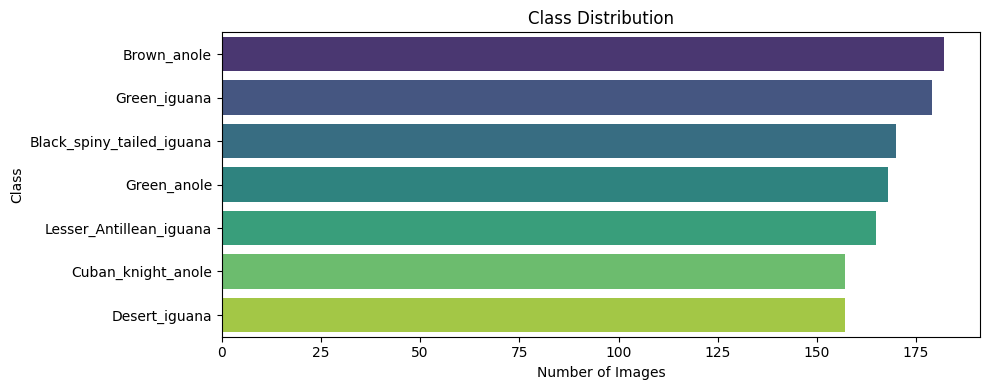

,count
label_name,
Brown_anole,182
Green_iguana,179
Black_spiny_tailed_iguana,170
Green_anole,168
Lesser_Antillean_iguana,165
Cuban_knight_anole,157
Desert_iguana,157


In [8]:
plt.figure(figsize=(10, 4))
order = df["label_name"].value_counts().index
sns.countplot(data=df, y="label_name", order=order, palette="viridis")
plt.title("Class Distribution")
plt.xlabel("Number of Images")
plt.ylabel("Class")
plt.tight_layout()
plt.show()

display(df["label_name"].value_counts().rename("count").to_frame())

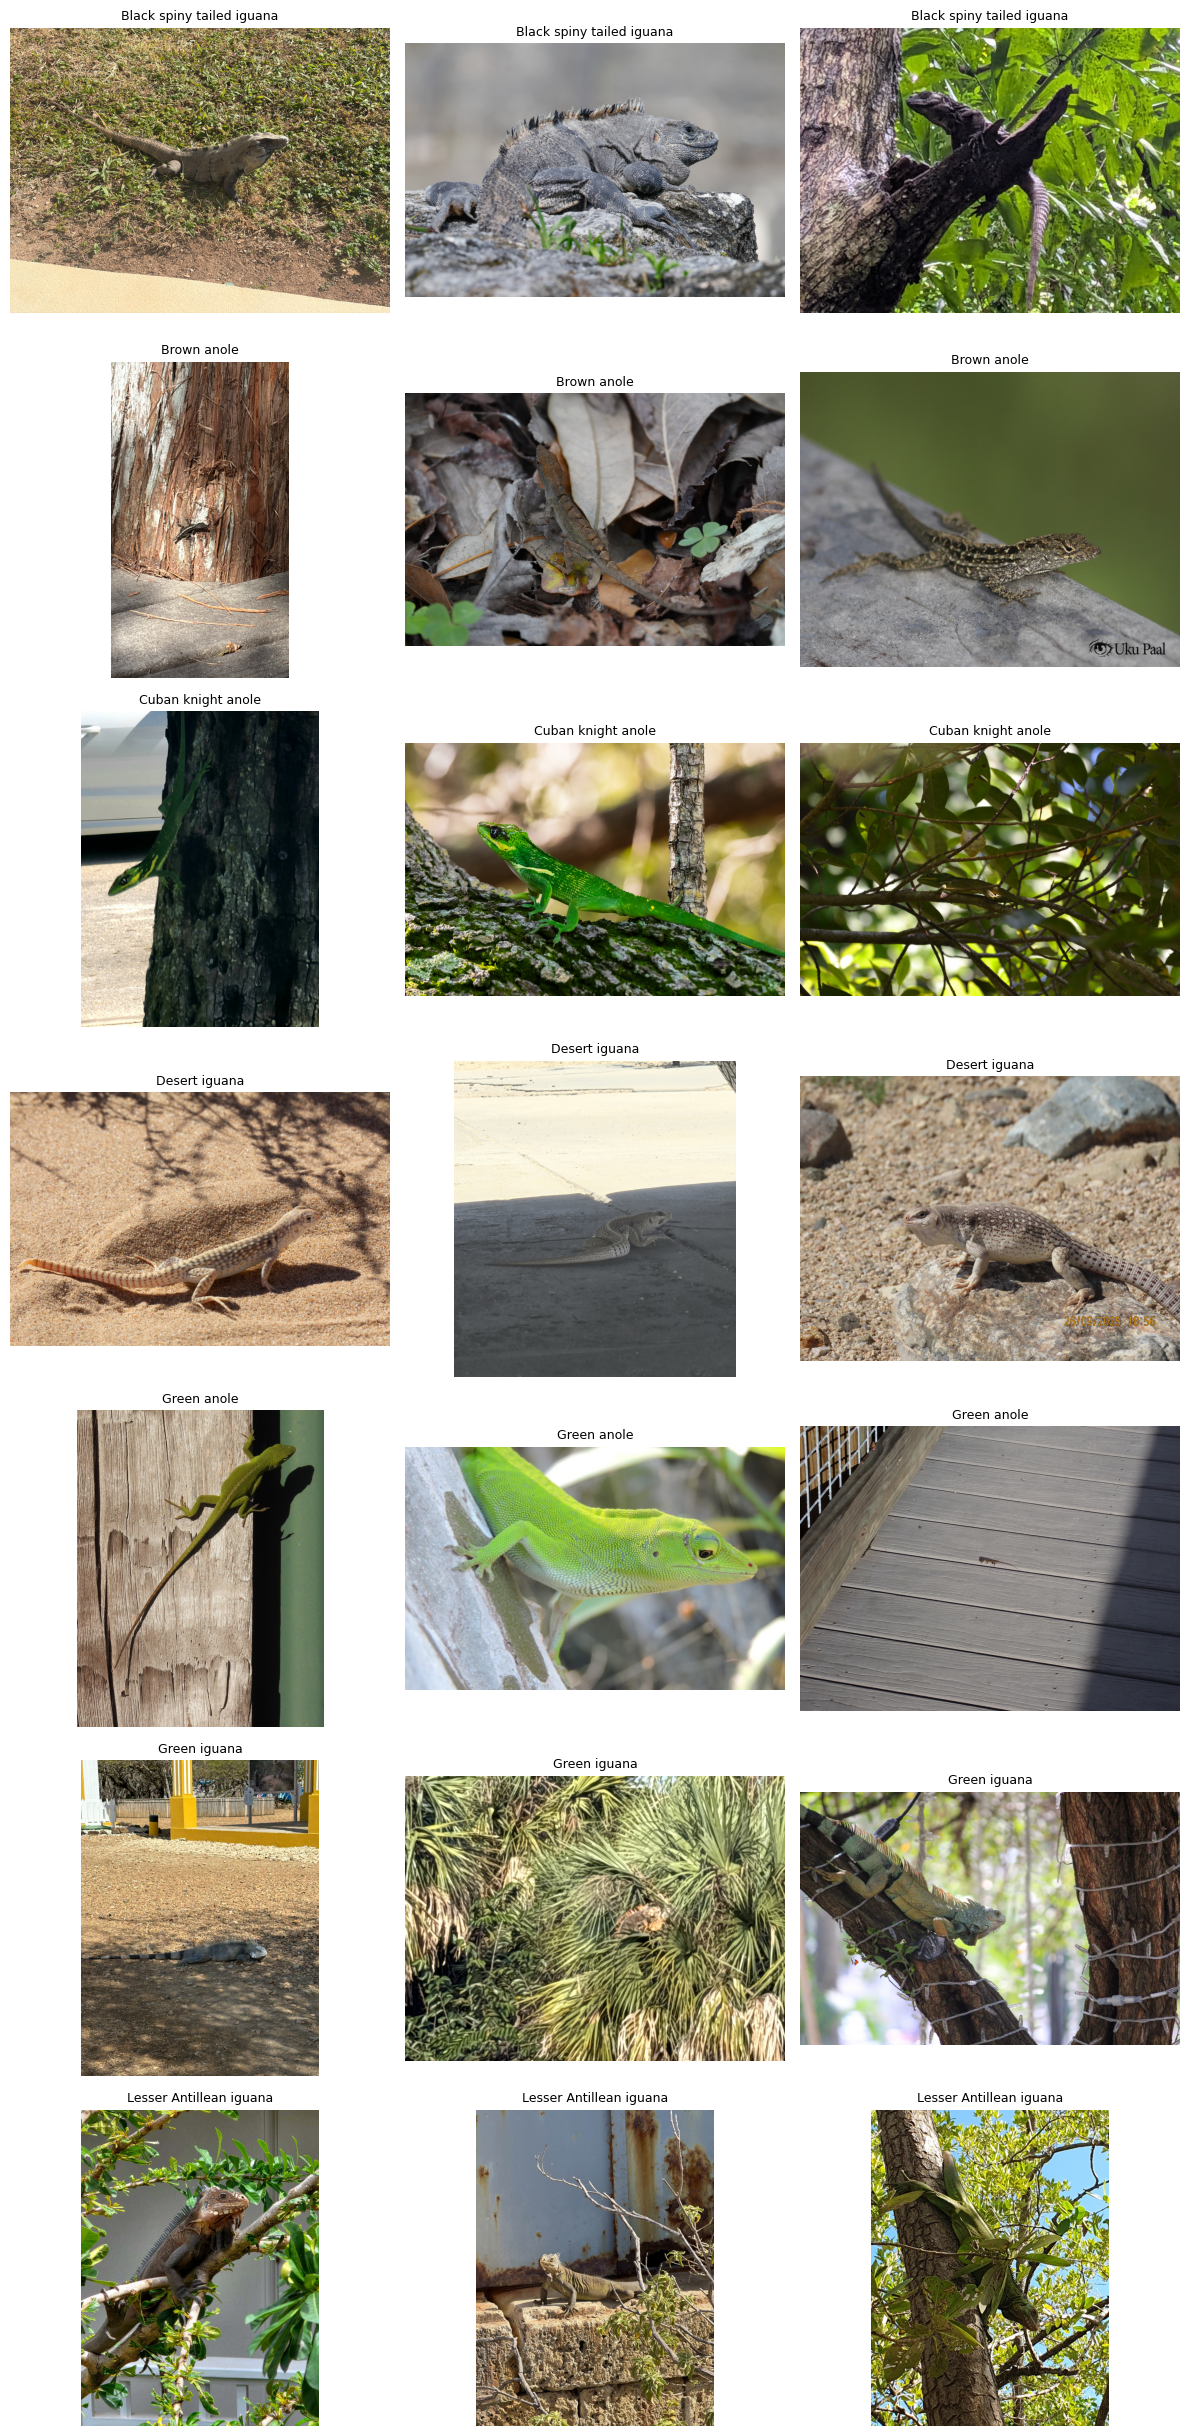

In [9]:
def show_sample_images(dataframe, n_per_class=3, seed=SEED):
    # Avoid groupby.apply here because Pandas 3.x excludes grouping columns by default.
    sampled_groups = []
    for label_name, group in dataframe.groupby("label_name", sort=True):
        sampled_groups.append(group.sample(n=min(len(group), n_per_class), random_state=seed))

    if not sampled_groups:
        print("No images available to display.")
        return

    sample_df = pd.concat(sampled_groups, ignore_index=True)
    n_cols = n_per_class
    n_rows = sample_df["label_name"].nunique()
    plt.figure(figsize=(4 * n_cols, 3.5 * n_rows))

    for i, row in enumerate(sample_df.itertuples(index=False), start=1):
        ax = plt.subplot(n_rows, n_cols, i)
        try:
            img = Image.open(row.filepath).convert("RGB")
            ax.imshow(img)
            title = str(row.label_name).replace("_", " ")
        except Exception as exc:
            title = f"Unreadable image\n{type(exc).__name__}"
        ax.set_title(title, fontsize=9)
        ax.axis("off")

    plt.tight_layout()
    plt.show()


show_sample_images(df, n_per_class=3)

In [10]:
def read_image_metadata(path):
    try:
        with Image.open(path) as img:
            return pd.Series(
                {
                    "width": img.width,
                    "height": img.height,
                    "mode": img.mode,
                    "aspect_ratio": img.width / img.height,
                    "readable": True,
                    "error": None,
                }
            )
    except Exception as exc:
        return pd.Series(
            {
                "width": np.nan,
                "height": np.nan,
                "mode": None,
                "aspect_ratio": np.nan,
                "readable": False,
                "error": str(exc),
            }
        )


metadata = df["filepath"].apply(read_image_metadata)
df = pd.concat([df, metadata], axis=1)

display(df[["width", "height", "aspect_ratio", "file_size_kb"]].describe())
print("Unreadable images:", (~df["readable"]).sum())
print("Image modes:")
display(df["mode"].value_counts(dropna=False).to_frame("count"))

,width,height,aspect_ratio,file_size_kb
count,1178.000000,1178.000000,1178.000000,1178.000000
mean,1652.521222,1709.244482,1.039012,1777.821122
std,375.475587,392.883145,0.389868,1047.041489
min,282.000000,293.000000,0.449707,45.693359
25%,1536.000000,1440.500000,0.750000,957.503174
50%,1536.000000,2048.000000,0.752930,1572.221191
75%,2048.000000,2048.000000,1.333333,2515.676270
max,2048.000000,2048.000000,2.659740,6003.945312


Unreadable images: 0
Image modes:


,count
mode,
RGB,1178


## 4. Data Quality / Cleaning

This section checks for unreadable/corrupt images with Pillow and uses CleanVision to identify issues such as blurry images, dark images, duplicates, near duplicates, and outliers. Removed images are moved to `removed images/` instead of being permanently deleted.

In [11]:
# Basic issue checks that are useful before using heavier tooling.
possible_issues = {
    "unreadable": df.loc[~df["readable"], ["filepath", "error"]],
    "very_small": df.loc[(df["width"] < 128) | (df["height"] < 128), ["filepath", "width", "height"]],
    "extreme_aspect_ratio": df.loc[
        (df["aspect_ratio"] < 0.5) | (df["aspect_ratio"] > 2.0),
        ["filepath", "width", "height", "aspect_ratio"],
    ],
    "tiny_file": df.loc[df["file_size_kb"] < 10, ["filepath", "file_size_kb"]],
    "duplicate_filename": df.loc[df["id"].duplicated(keep=False), ["id", "filepath", "label_name"]],
}

for issue_name, issue_df in possible_issues.items():
    print(f"{issue_name}: {len(issue_df)}")
    display(issue_df.head())

unreadable: 0


,filepath,error


very_small: 0


,filepath,width,height


extreme_aspect_ratio: 30


,filepath,width,height,aspect_ratio
70,c:\school programs\AI\ML_ENV\AI-Lizard-Predict...,946,2048,0.461914
162,c:\school programs\AI\ML_ENV\AI-Lizard-Predict...,921,2048,0.449707
291,c:\school programs\AI\ML_ENV\AI-Lizard-Predict...,395,855,0.461988
293,c:\school programs\AI\ML_ENV\AI-Lizard-Predict...,667,1383,0.482285
301,c:\school programs\AI\ML_ENV\AI-Lizard-Predict...,959,2048,0.468262


tiny_file: 0


,filepath,file_size_kb


duplicate_filename: 0


,id,filepath,label_name


In [12]:
def verify_images(dataframe):
    rows = []
    for row in dataframe.itertuples():
        try:
            with Image.open(row.filepath) as img:
                img.verify()
            rows.append({"filepath": row.filepath, "is_valid": True, "error": None})
        except (UnidentifiedImageError, OSError, ValueError) as exc:
            rows.append({"filepath": row.filepath, "is_valid": False, "error": str(exc)})
    return pd.DataFrame(rows)


verification_df = verify_images(df)
invalid_images = verification_df.loc[~verification_df["is_valid"]]
print(f"Invalid/corrupt images detected by Pillow: {len(invalid_images)}")
display(invalid_images.head())

Invalid/corrupt images detected by Pillow: 0


,filepath,is_valid,error


In [13]:
# Optional: move corrupt images to a quarantine folder instead of deleting them.
QUARANTINE_CORRUPT_IMAGES = False
QUARANTINE_DIR = ARTIFACTS_DIR / "quarantined_corrupt_images"

if QUARANTINE_CORRUPT_IMAGES and len(invalid_images) > 0:
    QUARANTINE_DIR.mkdir(parents=True, exist_ok=True)
    for path in invalid_images["filepath"]:
        path = Path(path)
        target = QUARANTINE_DIR / path.name
        shutil.move(str(path), str(target))
    print(f"Moved {len(invalid_images)} files to {QUARANTINE_DIR}")
else:
    print("No files moved. Keep QUARANTINE_CORRUPT_IMAGES = False until issues are reviewed.")

No files moved. Keep QUARANTINE_CORRUPT_IMAGES = False until issues are reviewed.


In [14]:
RUN_CLEANVISION = False  # Change to True to run image quality issue detection.

if RUN_CLEANVISION:
    try:
        from cleanvision import Imagelab

        imagelab = Imagelab(data_path=str(TRAIN_DIR))
        # n_jobs=1 is more reliable on Windows/Jupyter because multiprocessing can fail with PermissionError.
        imagelab.find_issues(n_jobs=1)

        cleanvision_issues = imagelab.issues
        cleanvision_summary = imagelab.issue_summary

        display(cleanvision_summary)
        display(cleanvision_issues.head())

        cleanvision_issues.reset_index(names="filepath").to_csv(REPORT_DIR / "cleanvision_issues.csv", index=False)
        cleanvision_summary.to_csv(REPORT_DIR / "cleanvision_issue_summary.csv", index=False)
    except ImportError:
        print("CleanVision is not installed. Install it with: %pip install cleanvision")
else:
    print("Set RUN_CLEANVISION = True to run CleanVision quality checks.")

Set RUN_CLEANVISION = True to run CleanVision quality checks.


### Same-Class Duplicate Quarantine

CleanVision detects duplicates across the full dataset. For this project, we only want to remove duplicate images when they occur inside the same specific class folder. If duplicate-looking images appear in different class folders, they are more important as potential label issues and should be reviewed manually instead of moved automatically.

The cell below keeps one image per duplicate group per class folder and moves the other duplicate files to `removed images/<class_name>/`. This preserves the removed files for documentation and recovery.

In [15]:
MOVE_SAME_CLASS_DUPLICATES = False  # Review the preview first, then set to True to move files.
REMOVED_IMAGES_DIR = ROOT / "removed images"

# We quarantine exact and near duplicates only when they occur inside the same class folder.
DUPLICATE_ISSUE_TYPES_TO_QUARANTINE = ["exact_duplicates", "near_duplicates"]


def unique_destination_path(destination_path):
    destination_path = Path(destination_path)
    if not destination_path.exists():
        return destination_path

    counter = 1
    while True:
        candidate = destination_path.with_name(
            f"{destination_path.stem}_duplicate_{counter}{destination_path.suffix}"
        )
        if not candidate.exists():
            return candidate
        counter += 1


def get_cleanvision_duplicate_sets(imagelab, issue_types):
    duplicate_sets = []
    for issue_type in issue_types:
        issue_info = imagelab.info.get(issue_type, {})
        for duplicate_group in issue_info.get("sets", []):
            duplicate_sets.append(
                {
                    "issue_type": issue_type,
                    "filepaths": [Path(path) for path in duplicate_group],
                }
            )
    return duplicate_sets


def plan_same_class_duplicate_moves(duplicate_sets, train_dir=TRAIN_DIR):
    move_rows = []
    for group_id, duplicate_group in enumerate(duplicate_sets):
        issue_type = duplicate_group["issue_type"]
        filepaths = duplicate_group["filepaths"]

        by_class_folder = {}
        for filepath in filepaths:
            # Only consider images that are still inside the training class folders.
            if not filepath.exists() or filepath.parent.parent.resolve() != train_dir.resolve():
                continue
            by_class_folder.setdefault(filepath.parent.name, []).append(filepath)

        for class_name, class_filepaths in by_class_folder.items():
            if len(class_filepaths) < 2:
                continue

            class_filepaths = sorted(class_filepaths, key=lambda path: path.name)
            kept_filepath = class_filepaths[0]
            for moved_filepath in class_filepaths[1:]:
                target_dir = REMOVED_IMAGES_DIR / class_name
                target_path = unique_destination_path(target_dir / moved_filepath.name)
                move_rows.append(
                    {
                        "issue_type": issue_type,
                        "duplicate_group_id": group_id,
                        "class_name": class_name,
                        "kept_filepath": str(kept_filepath),
                        "moved_filepath": str(moved_filepath),
                        "target_filepath": str(target_path),
                    }
                )
    return pd.DataFrame(move_rows)


if "imagelab" not in globals():
    print("Run the CleanVision cell first so imagelab.info contains duplicate groups.")
else:
    duplicate_sets = get_cleanvision_duplicate_sets(
        imagelab,
        DUPLICATE_ISSUE_TYPES_TO_QUARANTINE,
    )
    duplicate_move_plan = plan_same_class_duplicate_moves(duplicate_sets)

    print(f"Same-class duplicate files planned for quarantine: {len(duplicate_move_plan)}")
    display(duplicate_move_plan.head(30))
    duplicate_move_plan.to_csv(REPORT_DIR / "same_class_duplicate_move_plan.csv", index=False)

    if MOVE_SAME_CLASS_DUPLICATES and not duplicate_move_plan.empty:
        moved_rows = []
        for row in duplicate_move_plan.itertuples(index=False):
            source = Path(row.moved_filepath)
            target = Path(row.target_filepath)
            target.parent.mkdir(parents=True, exist_ok=True)

            if source.exists():
                target = unique_destination_path(target)
                shutil.move(str(source), str(target))
                moved_rows.append({**row._asdict(), "target_filepath": str(target)})

        moved_duplicates_df = pd.DataFrame(moved_rows)
        moved_duplicates_df.to_csv(REPORT_DIR / "same_class_duplicates_moved.csv", index=False)
        print(f"Moved {len(moved_duplicates_df)} duplicate files to: {REMOVED_IMAGES_DIR}")
    else:
        print("No files moved. Set MOVE_SAME_CLASS_DUPLICATES = True after reviewing the plan.")

Run the CleanVision cell first so imagelab.info contains duplicate groups.


### Visual Review: Odd-Size Images

Near duplicates inside the same class are quarantined by the duplicate-cleaning cell above because they add little new information and can make validation performance too optimistic. Odd-size images are kept: the model resizes every image to the same input size, and these samples are only larger or smaller than average rather than invalid. The grid below is only a quick sanity check for odd-size images.

In [16]:
def cleanvision_issues_with_filepaths(imagelab):
    issues = imagelab.issues.copy()
    issues["filepath"] = issues.index.astype(str)
    return issues.reset_index(drop=True)


def add_class_and_metadata(issue_df, base_df=df):
    meta_cols = ["filepath", "label_name", "width", "height", "file_size_kb"]
    available_cols = [col for col in meta_cols if col in base_df.columns]
    return issue_df.merge(base_df[available_cols], on="filepath", how="left")


def show_issue_images(issue_df, title, n=24, sort_col=None):
    review_df = issue_df.copy()
    review_df = review_df[review_df["filepath"].apply(lambda path: Path(path).exists())]
    if sort_col and sort_col in review_df.columns:
        review_df = review_df.sort_values(sort_col)
    review_df = review_df.head(n)

    if review_df.empty:
        print(f"No images to show for: {title}")
        return

    n_cols = 4
    n_rows = int(np.ceil(len(review_df) / n_cols))
    plt.figure(figsize=(4 * n_cols, 4 * n_rows))
    for i, row in enumerate(review_df.itertuples(index=False), start=1):
        ax = plt.subplot(n_rows, n_cols, i)
        image = Image.open(row.filepath).convert("RGB")
        ax.imshow(image)
        class_name = getattr(row, "label_name", "unknown")
        width = getattr(row, "width", image.width)
        height = getattr(row, "height", image.height)
        if pd.isna(width) or pd.isna(height):
            width, height = image.width, image.height
        ax.set_title(f"{class_name}\n{int(width)}x{int(height)}", fontsize=8)
        ax.axis("off")
    plt.suptitle(title, y=1.01, fontsize=14)
    plt.tight_layout()
    plt.show()
if "imagelab" not in globals():
    print("Run the CleanVision cell first, then run this review cell.")
else:
    review_issues = add_class_and_metadata(cleanvision_issues_with_filepaths(imagelab))

    odd_size_df = review_issues[review_issues["is_odd_size_issue"] == True] if "is_odd_size_issue" in review_issues else review_issues.iloc[0:0]
    print(f"Odd-size images to review: {len(odd_size_df)}")

    display(odd_size_df[["filepath", "label_name", "width", "height", "odd_size_score"]].head(30))
    show_issue_images(odd_size_df, "Odd-size images kept in dataset", n=24, sort_col="odd_size_score")

Run the CleanVision cell first, then run this review cell.


### Cleaning Findings

Use this section after running the cells above:

- Pillow validation checks whether files can be decoded.
- CleanVision flags quality issues such as blurry, dark, light, grayscale, odd aspect ratio, exact duplicates, and near-duplicates.
- Same-class exact and near duplicates are quarantined to `removed images/<class_name>/` because they add little extra information and can inflate validation performance.
- Cross-class duplicates should be reviewed manually because they may indicate label errors rather than files that should be removed automatically.
- Odd-size images are kept because image size differences are handled by resizing, and visual review showed these samples are still valid.
- In this project, suspicious files should be reviewed visually before removal because difficult lighting or unusual poses can still be valid examples of real lizards.

Decision rule used in this notebook: quarantine corrupt/unreadable files and same-class exact/near duplicates; keep odd-size images unless visual inspection shows that an image is invalid.

## 5. Data Preparation

We create a stratified train/validation/holdout-test split from the cleaned training set, resize images, apply EfficientNetV2 preprocessing inside the model, and build TensorFlow data loaders.

In [17]:
clean_df = df[df["readable"]].copy()

# After cleaning/quarantining images, some paths in df may point to files that were moved.
# Keep only files that still exist inside train/ before creating TensorFlow datasets.
clean_df["file_exists"] = clean_df["filepath"].apply(lambda path: Path(path).exists())
missing_after_cleaning = clean_df[~clean_df["file_exists"]].copy()
if len(missing_after_cleaning) > 0:
    print(f"Removed {len(missing_after_cleaning)} rows for images no longer present in train/.")
    display(missing_after_cleaning[["filepath", "label_name"]].head(20))

clean_df = clean_df[clean_df["file_exists"]].drop(columns="file_exists").reset_index(drop=True)


train_df, temp_df = train_test_split(
    clean_df,
    test_size=0.30,
    random_state=SEED,
    stratify=clean_df["label"],
)
val_df, holdout_test_df = train_test_split(
    temp_df,
    test_size=0.50,
    random_state=SEED,
    stratify=temp_df["label"],
)

class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.array(sorted(clean_df["label"].unique())),
    y=train_df["label"].values,
)
class_weight_dict = {
    class_id: float(weight)
    for class_id, weight in zip(sorted(clean_df["label"].unique()), class_weights)
}

print(f"Train: {len(train_df):,}")
print(f"Validation: {len(val_df):,}")
print(f"Holdout test: {len(holdout_test_df):,}")
print("Class weights:", class_weight_dict)

Train: 824
Validation: 177
Holdout test: 177
Class weights: {np.int64(0): 0.9891956782713085, np.int64(1): 0.9268841394825647, np.int64(2): 1.07012987012987, np.int64(3): 1.07012987012987, np.int64(4): 0.9975786924939467, np.int64(5): 0.9417142857142857, np.int64(6): 1.0236024844720497}


In [18]:
def decode_and_resize(path, label=None, img_size=IMG_SIZE):
    image_bytes = tf.io.read_file(path)
    image = tf.io.decode_image(image_bytes, channels=3, expand_animations=False)
    image = tf.image.resize(image, img_size)
    image = tf.cast(image, tf.float32)

    if label is None:
        return image
    return image, tf.cast(label, tf.int32)


def make_dataset(dataframe, batch_size=BATCH_SIZE, shuffle=False):
    paths = dataframe["filepath"].astype(str).values
    labels = dataframe["label"].astype(np.int32).values

    ds = tf.data.Dataset.from_tensor_slices((paths, labels))
    if shuffle:
        ds = ds.shuffle(buffer_size=len(dataframe), seed=SEED, reshuffle_each_iteration=True)
    ds = ds.map(decode_and_resize, num_parallel_calls=AUTOTUNE)
    ds = ds.batch(batch_size).prefetch(AUTOTUNE)
    return ds


train_ds = make_dataset(train_df, shuffle=True)
val_ds = make_dataset(val_df)
holdout_test_ds = make_dataset(holdout_test_df)

## 6. Data Augmentation

Augmentation is implemented with Keras preprocessing layers. We keep transformations realistic: flips, small rotations, mild zoom/translation, and small contrast changes. Heavy color changes are avoided because color and texture can be important visual cues for lizard species.

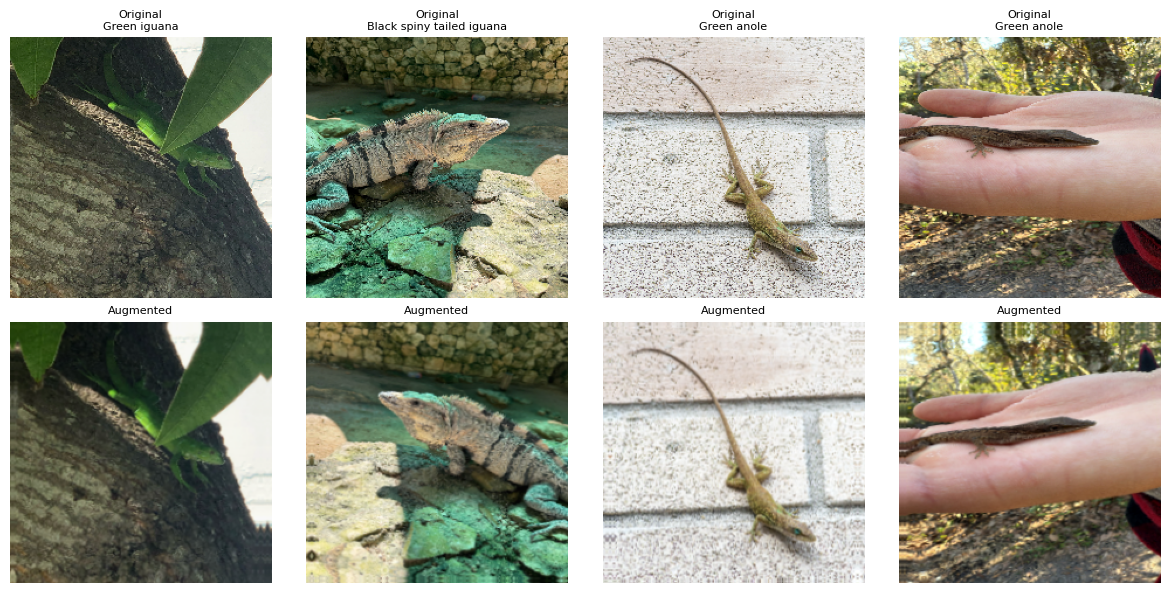

In [22]:
augmentation_layers = [
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.035),
    layers.RandomZoom(height_factor=(-0.05, 0.08), width_factor=(-0.05, 0.08)),
    layers.RandomTranslation(0.025, 0.025),
    layers.RandomContrast(0.08),
]
if hasattr(layers, "RandomBrightness"):
    augmentation_layers.append(layers.RandomBrightness(0.04))

data_augmentation = keras.Sequential(
    augmentation_layers,
    name="realistic_lizard_augmentation",
)


plt.figure(figsize=(12, 6))
for images, labels in train_ds.take(1):
    augmented = data_augmentation(images, training=True)
    n = min(4, images.shape[0])
    for i in range(n):
        ax = plt.subplot(2, n, i + 1)
        plt.imshow(tf.cast(images[i], tf.uint8))
        plt.title(f"Original\n{id_to_class[int(labels[i])].replace('_', ' ')}", fontsize=8)
        plt.axis("off")

        ax = plt.subplot(2, n, i + 1 + n)
        plt.imshow(tf.cast(tf.clip_by_value(augmented[i], 0, 255), tf.uint8))
        plt.title("Augmented", fontsize=8)
        plt.axis("off")
plt.tight_layout()
plt.show()


## 7. Baseline Model

The baseline uses transfer learning with EfficientNetV2B0. The pretrained backbone is frozen, and we train only a custom classification head. AdamW is used by default, with Adam available as an alternative.

In [23]:

def get_optimizer(name="adamw", learning_rate=1e-3, weight_decay=1e-4):
    name = name.lower()
    if name == "adamw":
        try:
            return keras.optimizers.AdamW(
                learning_rate=learning_rate,
                weight_decay=weight_decay,
            )
        except AttributeError:
            print("AdamW is unavailable in this Keras version. Falling back to Adam.")
            return keras.optimizers.Adam(learning_rate=learning_rate)
    if name == "adam":
        return keras.optimizers.Adam(learning_rate=learning_rate)
    raise ValueError(f"Unsupported optimizer: {name}")


BACKBONE_LAYER_NAME = "efficientnetv2-b0"


def compile_classifier_model(model, learning_rate, optimizer_name="adamw", weight_decay=1e-4):
    model.compile(
        optimizer=get_optimizer(
            optimizer_name,
            learning_rate=learning_rate,
            weight_decay=weight_decay,
        ),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"],
    )


def set_backbone_fine_tuning(model, fine_tune_last_n_layers=0):
    backbone = model.get_layer(BACKBONE_LAYER_NAME)
    fine_tune_last_n_layers = int(fine_tune_last_n_layers or 0)

    if fine_tune_last_n_layers <= 0:
        backbone.trainable = False
        for layer in backbone.layers:
            layer.trainable = False
        return

    backbone.trainable = True
    for layer in backbone.layers[:-fine_tune_last_n_layers]:
        layer.trainable = False
    for layer in backbone.layers[-fine_tune_last_n_layers:]:
        layer.trainable = True
    for layer in backbone.layers:
        if isinstance(layer, layers.BatchNormalization):
            layer.trainable = False


def build_model(
    num_classes,
    img_size=IMG_SIZE,
    dense_units=256,
    dropout_rate=0.30,
    learning_rate=1e-3,
    optimizer_name="adamw",
    weight_decay=1e-4,
):
    inputs = keras.Input(shape=(*img_size, 3), name="image")
    x = data_augmentation(inputs)

    backbone = keras.applications.EfficientNetV2B0(
        include_top=False,
        include_preprocessing=True,
        weights="imagenet",
        input_shape=(*img_size, 3),
        pooling="avg",
        name=BACKBONE_LAYER_NAME,
    )
    backbone.trainable = False

    # training=False keeps BatchNorm in the frozen backbone in inference mode.
    # Convolutional layers can still be fine-tuned after unfreezing.
    x = backbone(x, training=False)
    x = layers.BatchNormalization()(x)
    if dense_units > 0:
        x = layers.Dense(dense_units, activation="relu")(x)
        x = layers.BatchNormalization()(x)
    x = layers.Dropout(dropout_rate)(x)
    x = layers.Activation("linear", name="embedding_features")(x)
    outputs = layers.Dense(num_classes, activation="softmax", name="class_probabilities")(x)

    model = keras.Model(inputs, outputs, name="lizard_efficientnetv2b0")
    compile_classifier_model(
        model,
        learning_rate=learning_rate,
        optimizer_name=optimizer_name,
        weight_decay=weight_decay,
    )
    return model


baseline_params = {
    "dense_units": 256,
    "dropout_rate": 0.30,
    "learning_rate": 1e-3,
    "optimizer": "adamw",
    "weight_decay": 1e-4,
    "batch_size": BATCH_SIZE,
}

baseline_model = build_model(
    num_classes=len(class_names),
    dense_units=baseline_params["dense_units"],
    dropout_rate=baseline_params["dropout_rate"],
    learning_rate=baseline_params["learning_rate"],
    optimizer_name=baseline_params["optimizer"],
    weight_decay=baseline_params["weight_decay"],
)
baseline_model.summary()


Model: "lizard_efficientnetv2b0"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ image (InputLayer)              │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ realistic_lizard_augmentation   │ (None, 224, 224, 3)    │             0 │
│ (Sequential)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetv2-b0 (Functional)  │ (None, 1280)           │     5,919,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 1280)           │         5,120 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ embedding_features (Activation) │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ class_probabilities (Dense)     │ (None, 7)              │         1,799 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,255,191 (23.86 MB)

 Trainable params: 332,807 (1.27 MB)

 Non-trainable params: 5,922,384 (22.59 MB)

## 8. Baseline Training

The baseline is trained with validation monitoring, EarlyStopping, and ReduceLROnPlateau. TensorBoard logs and model checkpoints are disabled to avoid creating extra `artifacts/logs` and `artifacts/models` folders.

In [24]:
baseline_callbacks = [
    keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=6,
        restore_best_weights=True,
        verbose=1,
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.3,
        patience=3,
        min_lr=1e-6,
        verbose=1,
    ),
]

BASELINE_EPOCHS = 20

baseline_history = baseline_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=BASELINE_EPOCHS,
    callbacks=baseline_callbacks,
    class_weight=class_weight_dict,
)

Epoch 1/20
26/26 ━━━━━━━━━━━━━━━━━━━━ 30s 571ms/step - accuracy: 0.4005 - loss: 1.8983 - val_accuracy: 0.5650 - val_loss: 1.2996 - learning_rate: 0.0010
Epoch 2/20
26/26 ━━━━━━━━━━━━━━━━━━━━ 11s 401ms/step - accuracy: 0.6299 - loss: 1.0037 - val_accuracy: 0.5763 - val_loss: 1.1684 - learning_rate: 0.0010
Epoch 3/20
26/26 ━━━━━━━━━━━━━━━━━━━━ 11s 400ms/step - accuracy: 0.6845 - loss: 0.8676 - val_accuracy: 0.5593 - val_loss: 1.1293 - learning_rate: 0.0010
Epoch 4/20
26/26 ━━━━━━━━━━━━━━━━━━━━ 11s 401ms/step - accuracy: 0.7609 - loss: 0.6312 - val_accuracy: 0.5819 - val_loss: 1.1027 - learning_rate: 0.0010
Epoch 5/20
26/26 ━━━━━━━━━━━━━━━━━━━━ 11s 406ms/step - accuracy: 0.7973 - loss: 0.5388 - val_accuracy: 0.5593 - val_loss: 1.0918 - learning_rate: 0.0010
Epoch 6/20
26/26 ━━━━━━━━━━━━━━━━━━━━ 11s 403ms/step - accuracy: 0.8155 - loss: 0.5009 - val_accuracy: 0.5876 - val_loss: 1.0447 - learning_rate: 0.0010
Epoch 7/20
26/26 ━━━━━━━━━━━━━━━━━━━━ 13s 485ms/step - accuracy: 0.8228 - loss: 0.

In [25]:
# TensorBoard logging is disabled in this notebook to avoid creating artifacts/logs.
# If needed, add keras.callbacks.TensorBoard(log_dir=...) to the callbacks manually.

## 9. Baseline Evaluation

We evaluate the baseline with training curves, a confusion matrix, and a classification report. Detailed suspicious-label/error review is handled later with Cleanlab and Grad-CAM.

In [26]:

def plot_history(history_obj, title="Training History"):
    history_dict = history_obj.history
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    axes[0].plot(history_dict.get("loss", []), label="train")
    axes[0].plot(history_dict.get("val_loss", []), label="validation")
    axes[0].set_title(f"{title}: Loss")
    axes[0].set_xlabel("Epoch")
    axes[0].legend()

    axes[1].plot(history_dict.get("accuracy", []), label="train")
    axes[1].plot(history_dict.get("val_accuracy", []), label="validation")
    axes[1].set_title(f"{title}: Accuracy")
    axes[1].set_xlabel("Epoch")
    axes[1].legend()

    plt.tight_layout()
    plt.show()


def results_dataframe_from_probabilities(dataframe, probabilities):
    predictions = probabilities.argmax(axis=1)
    results = dataframe.copy().reset_index(drop=True)
    results["pred_label"] = predictions
    results["pred_name"] = results["pred_label"].map(id_to_class)
    results["confidence"] = probabilities.max(axis=1)
    return results


def predict_dataframe(model, dataset, dataframe):
    probabilities = model.predict(dataset)
    results = results_dataframe_from_probabilities(dataframe, probabilities)
    return results, probabilities


def metric_summary_from_probabilities(y_true, probabilities, name):
    predictions = probabilities.argmax(axis=1)
    return {
        "strategy": name,
        "accuracy": float(np.mean(predictions == y_true)),
        "macro_f1": float(f1_score(y_true, predictions, average="macro")),
        "weighted_f1": float(f1_score(y_true, predictions, average="weighted")),
    }


class ValidationMetricsCallback(keras.callbacks.Callback):
    def __init__(self, validation_data, validation_labels, prefix="val"):
        super().__init__()
        self.validation_data = validation_data
        self.validation_labels = np.asarray(validation_labels)
        self.prefix = prefix

    def on_epoch_end(self, epoch, logs=None):
        logs = logs or {}
        probabilities = self.model.predict(self.validation_data, verbose=0)
        predictions = probabilities.argmax(axis=1)
        logs[f"{self.prefix}_macro_f1"] = float(
            f1_score(self.validation_labels, predictions, average="macro")
        )
        logs[f"{self.prefix}_weighted_f1"] = float(
            f1_score(self.validation_labels, predictions, average="weighted")
        )
        logs[f"{self.prefix}_eval_accuracy"] = float(
            np.mean(predictions == self.validation_labels)
        )


def plot_confusion(y_true, y_pred, title="Confusion Matrix"):
    cm = confusion_matrix(y_true, y_pred, labels=list(range(len(class_names))))
    plt.figure(figsize=(8, 6))
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=[name.replace("_", "\n") for name in class_names],
        yticklabels=[name.replace("_", "\n") for name in class_names],
    )
    plt.title(title)
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.tight_layout()
    plt.show()


def horizontal_flip_dataset(dataset):
    if isinstance(dataset.element_spec, tuple):
        return dataset.map(
            lambda images, labels: (tf.image.flip_left_right(images), labels),
            num_parallel_calls=AUTOTUNE,
        ).prefetch(AUTOTUNE)
    return dataset.map(
        lambda images: tf.image.flip_left_right(images),
        num_parallel_calls=AUTOTUNE,
    ).prefetch(AUTOTUNE)


def build_feature_extractor(model):
    try:
        embedding_output = model.get_layer("embedding_features").output
    except ValueError:
        embedding_output = model.layers[-2].output
    return keras.Model(model.input, embedding_output, name="embedding_extractor")


def extract_embeddings(feature_model, dataset):
    return feature_model.predict(dataset, verbose=0)


def l2_normalize(embeddings):
    norms = np.linalg.norm(embeddings, axis=1, keepdims=True)
    return embeddings / np.maximum(norms, 1e-8)


def compute_knn_probabilities(train_embeddings, train_labels, query_embeddings, k, temperature, num_classes):
    k = min(int(k), len(train_labels))
    similarities = query_embeddings @ train_embeddings.T
    top_idx = np.argpartition(-similarities, kth=k - 1, axis=1)[:, :k]
    top_similarities = np.take_along_axis(similarities, top_idx, axis=1)
    order = np.argsort(-top_similarities, axis=1)
    top_idx = np.take_along_axis(top_idx, order, axis=1)
    top_similarities = np.take_along_axis(top_similarities, order, axis=1)

    weights = np.exp(top_similarities / max(float(temperature), 1e-6))
    weights = weights / np.maximum(weights.sum(axis=1, keepdims=True), 1e-8)

    probabilities = np.zeros((len(query_embeddings), num_classes), dtype=np.float32)
    for row_idx in range(len(query_embeddings)):
        for neighbour_idx in range(k):
            label = int(train_labels[top_idx[row_idx, neighbour_idx]])
            probabilities[row_idx, label] += float(weights[row_idx, neighbour_idx])
    return probabilities


def search_inference_strategies(model, feature_model, train_eval_ds, train_labels, selection_ds, selection_labels):
    train_embeddings = l2_normalize(extract_embeddings(feature_model, train_eval_ds))
    selection_embeddings_orig = l2_normalize(extract_embeddings(feature_model, selection_ds))
    selection_embeddings_flip = l2_normalize(extract_embeddings(feature_model, horizontal_flip_dataset(selection_ds)))

    base_probabilities = model.predict(selection_ds, verbose=0)
    flip_probabilities = model.predict(horizontal_flip_dataset(selection_ds), verbose=0)
    tta_probabilities = (base_probabilities + flip_probabilities) / 2.0

    candidates = []

    def register(strategy_name, probabilities, metadata):
        summary = metric_summary_from_probabilities(selection_labels, probabilities, strategy_name)
        candidates.append({
            "strategy_name": strategy_name,
            "probabilities": probabilities,
            "metadata": metadata,
            **summary,
        })

    register("single-pass softmax", base_probabilities, {"family": "softmax"})
    register("flip-TTA softmax", tta_probabilities, {"family": "softmax_tta"})

    if INFERENCE_SEARCH_MODE == "auto":
        embedding_variants = {
            "orig": selection_embeddings_orig,
            "flip_only": selection_embeddings_flip,
            "flip_avg": l2_normalize((selection_embeddings_orig + selection_embeddings_flip) / 2.0),
        }
        for embedding_variant, query_embeddings in embedding_variants.items():
            for temperature in KNN_TEMPERATURES:
                for k in KNN_NEIGHBORS:
                    knn_probabilities = compute_knn_probabilities(
                        train_embeddings=train_embeddings,
                        train_labels=train_labels,
                        query_embeddings=query_embeddings,
                        k=k,
                        temperature=temperature,
                        num_classes=len(class_names),
                    )
                    register(
                        f"kNN only ({embedding_variant}, k={k}, temp={temperature:.2f})",
                        knn_probabilities,
                        {
                            "family": "knn",
                            "embedding_variant": embedding_variant,
                            "k": k,
                            "temperature": temperature,
                        },
                    )
                    for alpha in BLEND_ALPHAS:
                        blended_probabilities = alpha * tta_probabilities + (1.0 - alpha) * knn_probabilities
                        register(
                            f"blend TTA + kNN ({embedding_variant}, k={k}, temp={temperature:.2f}, alpha={alpha:.2f})",
                            blended_probabilities,
                            {
                                "family": "blend",
                                "embedding_variant": embedding_variant,
                                "k": k,
                                "temperature": temperature,
                                "alpha": float(alpha),
                            },
                        )

    results_df = (
        pd.DataFrame(
            [
                {
                    "strategy": candidate["strategy_name"],
                    "accuracy": candidate["accuracy"],
                    "macro_f1": candidate["macro_f1"],
                    "weighted_f1": candidate["weighted_f1"],
                }
                for candidate in candidates
            ]
        )
        .sort_values(["macro_f1", "accuracy"], ascending=False)
        .reset_index(drop=True)
    )
    best_candidate = max(candidates, key=lambda item: (item["macro_f1"], item["accuracy"]))
    assets = {"train_embeddings": train_embeddings, "train_labels": np.asarray(train_labels)}
    return results_df, best_candidate, assets


def predict_with_inference_strategy(model, feature_model, dataset, metadata, train_embeddings, train_labels):
    base_probabilities = model.predict(dataset, verbose=0)
    if metadata.get("family") == "softmax":
        return base_probabilities

    flip_probabilities = model.predict(horizontal_flip_dataset(dataset), verbose=0)
    tta_probabilities = (base_probabilities + flip_probabilities) / 2.0
    if metadata.get("family") == "softmax_tta":
        return tta_probabilities

    embeddings_orig = l2_normalize(extract_embeddings(feature_model, dataset))
    embeddings_flip = l2_normalize(extract_embeddings(feature_model, horizontal_flip_dataset(dataset)))
    embedding_variant = metadata.get("embedding_variant", "orig")
    if embedding_variant == "flip_only":
        query_embeddings = embeddings_flip
    elif embedding_variant == "flip_avg":
        query_embeddings = l2_normalize((embeddings_orig + embeddings_flip) / 2.0)
    else:
        query_embeddings = embeddings_orig

    knn_probabilities = compute_knn_probabilities(
        train_embeddings=train_embeddings,
        train_labels=train_labels,
        query_embeddings=query_embeddings,
        k=metadata["k"],
        temperature=metadata["temperature"],
        num_classes=len(class_names),
    )
    if metadata.get("family") == "knn":
        return knn_probabilities

    alpha = float(metadata["alpha"])
    return alpha * tta_probabilities + (1.0 - alpha) * knn_probabilities


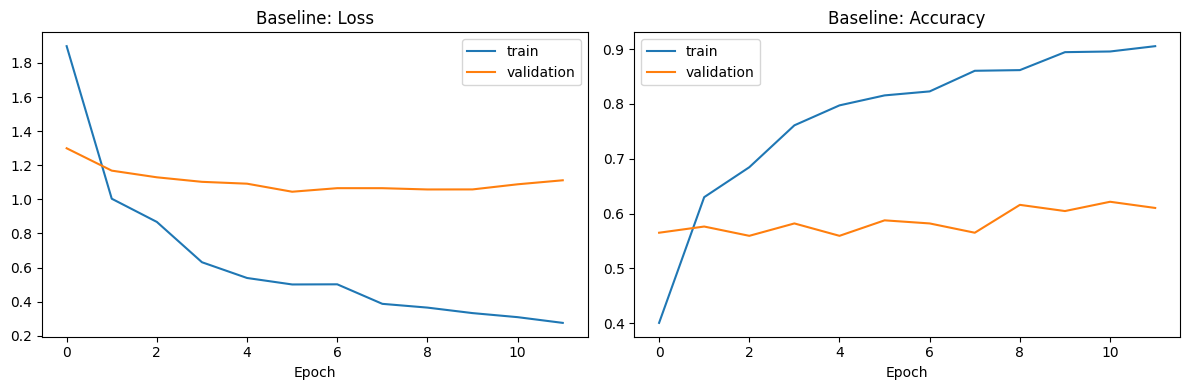

6/6 ━━━━━━━━━━━━━━━━━━━━ 5s 610ms/step
                           precision    recall  f1-score   support

Black_spiny_tailed_iguana       0.54      0.56      0.55        25
              Brown_anole       0.53      0.59      0.56        27
       Cuban_knight_anole       0.52      0.67      0.58        24
            Desert_iguana       0.94      0.71      0.81        24
              Green_anole       0.52      0.44      0.48        25
             Green_iguana       0.43      0.33      0.38        27
  Lesser_Antillean_iguana       0.50      0.60      0.55        25

                 accuracy                           0.55       177
                macro avg       0.57      0.56      0.56       177
             weighted avg       0.57      0.55      0.55       177



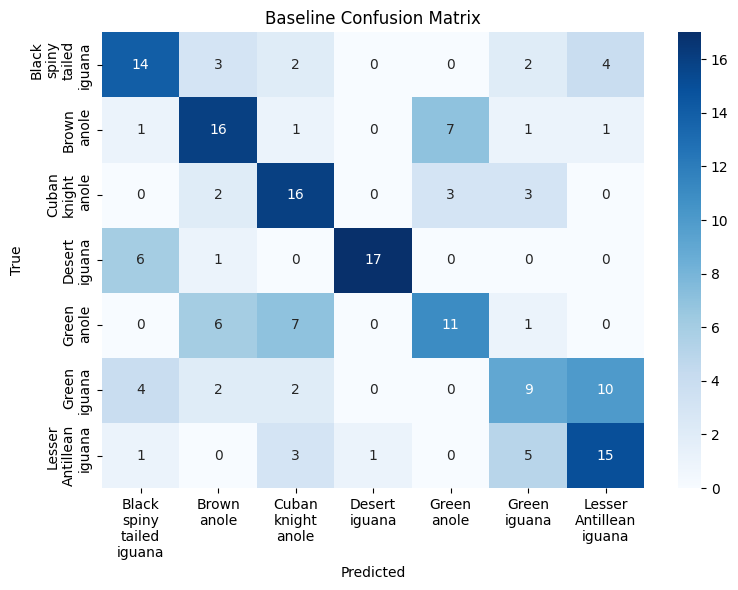

In [27]:
plot_history(baseline_history, title="Baseline")

baseline_results_df, baseline_probabilities = predict_dataframe(
    baseline_model,
    holdout_test_ds,
    holdout_test_df,
)
baseline_y_true = baseline_results_df["label"].values
baseline_y_pred = baseline_results_df["pred_label"].values

print(classification_report(baseline_y_true, baseline_y_pred, target_names=class_names))
plot_confusion(baseline_y_true, baseline_y_pred, title="Baseline Confusion Matrix")

## 10. Hyperparameter Tuning

Optuna runs multiple training trials after the baseline evaluation. We tune learning rate, batch size, dropout, optimizer, dense head size, and weight decay. Hyperband prunes weak trials early to reduce wasted training time.

In [ ]:

import gc
import optuna


class KerasPruningCallback(keras.callbacks.Callback):
    def __init__(self, trial, monitor="val_macro_f1", step_offset=0):
        super().__init__()
        self.trial = trial
        self.monitor = monitor
        self.step_offset = int(step_offset)

    def on_epoch_end(self, epoch, logs=None):
        logs = logs or {}
        value = logs.get(self.monitor)
        if value is None:
            return
        self.trial.report(float(value), step=self.step_offset + epoch)
        if self.trial.should_prune():
            raise optuna.TrialPruned(f"Trial pruned at epoch {self.step_offset + epoch}.")


def make_trial_callbacks(trial, validation_data, validation_labels, step_offset=0, patience=3):
    return [
        ValidationMetricsCallback(validation_data, validation_labels),
        KerasPruningCallback(trial, monitor="val_macro_f1", step_offset=step_offset),
        keras.callbacks.EarlyStopping(
            monitor="val_macro_f1",
            mode="max",
            patience=patience,
            restore_best_weights=True,
        ),
        keras.callbacks.ReduceLROnPlateau(
            monitor="val_macro_f1",
            mode="max",
            factor=0.3,
            patience=2,
            min_lr=1e-6,
        ),
    ]


def probabilities_for_trial_strategy(model, train_eval_ds, train_labels, validation_ds, trial_params):
    base_probabilities = model.predict(validation_ds, verbose=0)
    family = trial_params["inference_family"]
    if family == "softmax":
        return base_probabilities

    flip_probabilities = model.predict(horizontal_flip_dataset(validation_ds), verbose=0)
    tta_probabilities = (base_probabilities + flip_probabilities) / 2.0
    if family == "softmax_tta":
        return tta_probabilities

    feature_model = build_feature_extractor(model)
    train_embeddings = l2_normalize(extract_embeddings(feature_model, train_eval_ds))
    val_embeddings_orig = l2_normalize(extract_embeddings(feature_model, validation_ds))
    val_embeddings_flip = l2_normalize(extract_embeddings(feature_model, horizontal_flip_dataset(validation_ds)))

    embedding_variant = trial_params["embedding_variant"]
    if embedding_variant == "flip_only":
        query_embeddings = val_embeddings_flip
    elif embedding_variant == "flip_avg":
        query_embeddings = l2_normalize((val_embeddings_orig + val_embeddings_flip) / 2.0)
    else:
        query_embeddings = val_embeddings_orig

    knn_probabilities = compute_knn_probabilities(
        train_embeddings=train_embeddings,
        train_labels=train_labels,
        query_embeddings=query_embeddings,
        k=trial_params["knn_k"],
        temperature=trial_params["knn_temperature"],
        num_classes=len(class_names),
    )
    if family == "knn":
        return knn_probabilities

    alpha = float(trial_params["blend_alpha"])
    return alpha * tta_probabilities + (1.0 - alpha) * knn_probabilities


def objective(trial):
    trial_params = {
        "learning_rate": trial.suggest_float("learning_rate", 1e-5, 3e-3, log=True),
        "dropout_rate": trial.suggest_float("dropout_rate", 0.15, 0.55),
        "dense_units": trial.suggest_categorical("dense_units", OPTUNA_DENSE_CHOICES),
        "optimizer": trial.suggest_categorical("optimizer", ["adam", "adamw"]),
        "weight_decay": trial.suggest_float("weight_decay", 1e-6, 1e-3, log=True),
        "batch_size": trial.suggest_categorical("batch_size", OPTUNA_BATCH_CHOICES),
        "use_fine_tuning": trial.suggest_categorical(
            "use_fine_tuning", [False, True] if OPTUNA_SEARCH_FINE_TUNING else [False]
        ),
        "inference_family": trial.suggest_categorical("inference_family", OPTUNA_INFERENCE_FAMILIES),
        "embedding_variant": trial.suggest_categorical("embedding_variant", OPTUNA_EMBEDDING_VARIANTS),
        "knn_k": trial.suggest_categorical("knn_k", OPTUNA_KNN_NEIGHBORS),
        "knn_temperature": trial.suggest_categorical("knn_temperature", OPTUNA_KNN_TEMPERATURES),
        "blend_alpha": trial.suggest_float("blend_alpha", 0.0, 1.0),
        "head_epochs": OPTUNA_HEAD_MAX_EPOCHS,
    }

    if trial_params["use_fine_tuning"]:
        trial_params.update(
            {
                "fine_tune_last_n_layers": trial.suggest_categorical(
                    "fine_tune_last_n_layers", [10, 20, 40, 80]
                ),
                "fine_tune_learning_rate": trial.suggest_float(
                    "fine_tune_learning_rate", 1e-6, 5e-5, log=True
                ),
                "fine_tune_epochs": trial.suggest_int("fine_tune_epochs", 3, OPTUNA_FINE_TUNE_MAX_EPOCHS),
            }
        )
    else:
        trial_params.update(
            {
                "fine_tune_last_n_layers": 0,
                "fine_tune_learning_rate": 1e-6,
                "fine_tune_epochs": 0,
            }
        )

    trial_train_ds = make_dataset(train_df, batch_size=trial_params["batch_size"], shuffle=True)
    trial_train_eval_ds = make_dataset(train_df, batch_size=trial_params["batch_size"], shuffle=False)
    trial_val_ds = make_dataset(val_df, batch_size=trial_params["batch_size"])
    trial_val_labels = val_df["label"].to_numpy()
    trial_train_labels = train_df["label"].to_numpy()

    trial_model = build_model(
        num_classes=len(class_names),
        dense_units=trial_params["dense_units"],
        dropout_rate=trial_params["dropout_rate"],
        learning_rate=trial_params["learning_rate"],
        optimizer_name=trial_params["optimizer"],
        weight_decay=trial_params["weight_decay"],
    )

    try:
        trial_model.fit(
            trial_train_ds,
            validation_data=trial_val_ds,
            epochs=OPTUNA_HEAD_MAX_EPOCHS,
            callbacks=make_trial_callbacks(
                trial,
                validation_data=trial_val_ds,
                validation_labels=trial_val_labels,
                step_offset=0,
            ),
            verbose=0,
            class_weight=class_weight_dict,
        )

        if trial_params["use_fine_tuning"]:
            set_backbone_fine_tuning(trial_model, trial_params["fine_tune_last_n_layers"])
            compile_classifier_model(
                trial_model,
                learning_rate=trial_params["fine_tune_learning_rate"],
                optimizer_name=trial_params["optimizer"],
                weight_decay=trial_params["weight_decay"],
            )
            trial_model.fit(
                trial_train_ds,
                validation_data=trial_val_ds,
                epochs=trial_params["fine_tune_epochs"],
                callbacks=make_trial_callbacks(
                    trial,
                    validation_data=trial_val_ds,
                    validation_labels=trial_val_labels,
                    step_offset=OPTUNA_HEAD_MAX_EPOCHS,
                    patience=2,
                ),
                verbose=0,
                class_weight=class_weight_dict,
            )

        val_probabilities = probabilities_for_trial_strategy(
            model=trial_model,
            train_eval_ds=trial_train_eval_ds,
            train_labels=trial_train_labels,
            validation_ds=trial_val_ds,
            trial_params=trial_params,
        )
        summary = metric_summary_from_probabilities(trial_val_labels, val_probabilities, "trial_strategy")
        trial.set_user_attr("macro_f1", summary["macro_f1"])
        trial.set_user_attr("weighted_f1", summary["weighted_f1"])
        trial.set_user_attr("accuracy", summary["accuracy"])
        trial.set_user_attr("trial_params", trial_params)
        return summary["macro_f1"]
    finally:
        keras.backend.clear_session()
        gc.collect()


if RUN_OPTUNA:
    study = optuna.create_study(
        direction="maximize",
        pruner=optuna.pruners.HyperbandPruner(
            min_resource=OPTUNA_HYPERBAND_MIN_RESOURCE,
            max_resource=OPTUNA_HYPERBAND_MAX_RESOURCE,
            reduction_factor=OPTUNA_HYPERBAND_REDUCTION_FACTOR,
        ),
        study_name="lizard_macro_f1_training_and_inference_tuning",
    )
    study.optimize(objective, n_trials=N_OPTUNA_TRIALS)

    optuna_best_params = dict(study.best_params)
    optuna_best_score = float(study.best_value)
    optuna_best_user_attrs = dict(study.best_trial.user_attrs)

    print("Best validation macro-F1 found by Optuna:", optuna_best_score)
    print("Best validation metrics:")
    display(pd.DataFrame([{k: v for k, v in optuna_best_user_attrs.items() if k != "trial_params"}]))
    print("Best parameters found by Optuna:")
    display(pd.DataFrame([optuna_best_params]))
else:
    optuna_best_params = None
    optuna_best_score = None
    optuna_best_user_attrs = {}
    print("Optuna skipped. Final training will use fallback parameters.")


## 11. Final Model Training

The final model uses the best parameters from the completed Optuna run, hardcoded directly below so this section can be executed without rerunning the Optuna search. The custom head is trained with the EfficientNetV2B0 backbone frozen. Fine-tuning is optional and disabled by default, because the latest run increased validation loss instead of improving the model. The holdout test split remains untouched for final local evaluation.

In [ ]:

# Fallback parameters from the previous completed run.
# If the Optuna cell above has been run, these are replaced by optuna_best_params.
FALLBACK_BEST_PARAMS = {
    "learning_rate": 0.0005740256313054617,
    "dropout_rate": 0.26042387957550467,
    "dense_units": 128,
    "optimizer": "adamw",
    "weight_decay": 2.736697735605375e-06,
    "batch_size": 32,
    "use_fine_tuning": False,
    "fine_tune_last_n_layers": 0,
    "fine_tune_learning_rate": 1e-6,
    "fine_tune_epochs": 0,
    "inference_family": "softmax_tta",
    "embedding_variant": "flip_avg",
    "knn_k": 31,
    "knn_temperature": 0.15,
    "blend_alpha": 0.34,
}

BEST_PARAMS = FALLBACK_BEST_PARAMS.copy()
if "optuna_best_params" in globals() and optuna_best_params:
    BEST_PARAMS.update(optuna_best_params)
    BEST_OPTUNA_SCORE = optuna_best_score
    print("Optuna parameters used for final training:")
else:
    BEST_OPTUNA_SCORE = None
    print("Fallback parameters used for final training:")

display(pd.DataFrame([BEST_PARAMS]))

BEST_BATCH_SIZE = int(BEST_PARAMS["batch_size"])
FINAL_HEAD_EPOCHS = FINAL_HEAD_MAX_EPOCHS
BEST_PARAMS["head_epochs"] = FINAL_HEAD_EPOCHS
RUN_FINE_TUNING = bool(BEST_PARAMS.get("use_fine_tuning", False))
FINE_TUNE_LAST_N_LAYERS = int(BEST_PARAMS.get("fine_tune_last_n_layers", 0))
FINE_TUNE_EPOCHS = int(BEST_PARAMS.get("fine_tune_epochs", 0))
FINE_TUNE_LEARNING_RATE = float(BEST_PARAMS.get("fine_tune_learning_rate", 1e-6))

final_train_df = train_df.copy()
final_train_ds = make_dataset(final_train_df, batch_size=BEST_BATCH_SIZE, shuffle=True)
final_val_ds = make_dataset(val_df, batch_size=BEST_BATCH_SIZE)
final_holdout_ds = make_dataset(holdout_test_df, batch_size=BEST_BATCH_SIZE)
final_val_labels = val_df["label"].to_numpy()

final_model = build_model(
    num_classes=len(class_names),
    dense_units=int(BEST_PARAMS["dense_units"]),
    dropout_rate=float(BEST_PARAMS["dropout_rate"]),
    learning_rate=float(BEST_PARAMS["learning_rate"]),
    optimizer_name=BEST_PARAMS["optimizer"],
    weight_decay=float(BEST_PARAMS["weight_decay"]),
)


def make_final_callbacks(patience=5):
    return [
        ValidationMetricsCallback(final_val_ds, final_val_labels),
        keras.callbacks.EarlyStopping(
            monitor="val_macro_f1",
            mode="max",
            patience=patience,
            restore_best_weights=True,
            verbose=1,
        ),
        keras.callbacks.ReduceLROnPlateau(
            monitor="val_macro_f1",
            mode="max",
            factor=0.3,
            patience=2,
            min_lr=1e-6,
            verbose=1,
        ),
    ]


final_history = final_model.fit(
    final_train_ds,
    validation_data=final_val_ds,
    epochs=FINAL_HEAD_EPOCHS,
    callbacks=make_final_callbacks(),
    class_weight=class_weight_dict,
)

if RUN_FINE_TUNING and FINE_TUNE_LAST_N_LAYERS > 0 and FINE_TUNE_EPOCHS > 0:
    set_backbone_fine_tuning(final_model, FINE_TUNE_LAST_N_LAYERS)
    compile_classifier_model(
        final_model,
        learning_rate=FINE_TUNE_LEARNING_RATE,
        optimizer_name=BEST_PARAMS["optimizer"],
        weight_decay=float(BEST_PARAMS["weight_decay"]),
    )
    fine_tune_history = final_model.fit(
        final_train_ds,
        validation_data=final_val_ds,
        epochs=FINE_TUNE_EPOCHS,
        callbacks=make_final_callbacks(patience=3),
        class_weight=class_weight_dict,
    )
else:
    fine_tune_history = None

print("Final head epochs:", FINAL_HEAD_EPOCHS)
print("Fine-tuning enabled:", RUN_FINE_TUNING)
print("Fine-tuned backbone layers:", FINE_TUNE_LAST_N_LAYERS if RUN_FINE_TUNING else 0)
print("Primary training selection metric: validation macro-F1")


## 12. Final Evaluation

We evaluate the final model on the untouched holdout split, show the final training curves, confusion matrix, and classification report, and create the Kaggle submission file. Suspicious high-confidence errors are reviewed in the Cleanlab label-check section.

In [ ]:

plot_history(final_history, title="Final Model Head Training")
if fine_tune_history is not None:
    plot_history(fine_tune_history, title="Final Model Fine-tuning")

final_train_eval_ds = make_dataset(final_train_df, batch_size=BEST_BATCH_SIZE, shuffle=False)
final_feature_model = build_feature_extractor(final_model)
train_embedding_labels = final_train_df["label"].to_numpy()
val_labels = val_df["label"].to_numpy()
holdout_labels = holdout_test_df["label"].to_numpy()

inference_results_df, best_inference_candidate, inference_assets = search_inference_strategies(
    model=final_model,
    feature_model=final_feature_model,
    train_eval_ds=final_train_eval_ds,
    train_labels=train_embedding_labels,
    selection_ds=final_val_ds,
    selection_labels=val_labels,
)

display(inference_results_df.head(10))

selected_inference_metadata = dict(best_inference_candidate["metadata"])
final_inference_strategy = best_inference_candidate["strategy_name"]

print(f"Selected inference strategy by validation macro-F1: {final_inference_strategy}")
print(f"Validation macro-F1: {best_inference_candidate['macro_f1']:.4f}")
print(f"Validation weighted-F1: {best_inference_candidate['weighted_f1']:.4f}")
print(f"Validation accuracy: {best_inference_candidate['accuracy']:.4f}")
print("Selected inference metadata:", selected_inference_metadata)

holdout_softmax_probabilities = final_model.predict(final_holdout_ds, verbose=0)
holdout_tta_probabilities = (
    holdout_softmax_probabilities + final_model.predict(horizontal_flip_dataset(final_holdout_ds), verbose=0)
) / 2.0
final_holdout_probabilities = predict_with_inference_strategy(
    model=final_model,
    feature_model=final_feature_model,
    dataset=final_holdout_ds,
    metadata=selected_inference_metadata,
    train_embeddings=inference_assets["train_embeddings"],
    train_labels=inference_assets["train_labels"],
)

holdout_metric_table = pd.DataFrame(
    [
        metric_summary_from_probabilities(holdout_labels, holdout_softmax_probabilities, "single-pass softmax"),
        metric_summary_from_probabilities(holdout_labels, holdout_tta_probabilities, "flip-TTA softmax"),
        metric_summary_from_probabilities(holdout_labels, final_holdout_probabilities, final_inference_strategy),
    ]
).sort_values(["macro_f1", "accuracy"], ascending=False)

display(holdout_metric_table)

final_results_df = results_dataframe_from_probabilities(holdout_test_df, final_holdout_probabilities)
final_y_true = final_results_df["label"].values
final_y_pred = final_results_df["pred_label"].values

print(classification_report(final_y_true, final_y_pred, target_names=class_names))
plot_confusion(final_y_true, final_y_pred, title="Final Model Confusion Matrix")


In [ ]:

def make_test_dataframe(test_dir=TEST_DIR, test_csv=TEST_CSV):
    test_paths = list_image_files(test_dir)
    test_df = pd.DataFrame({"filepath": [str(p) for p in test_paths], "filename": [p.name for p in test_paths]})

    if test_csv.exists():
        meta = pd.read_csv(test_csv)
        meta["filename"] = meta["id"].astype(str) + ".jpg"
        test_df = meta.merge(test_df, on="filename", how="left")
    else:
        test_df["id"] = test_df["filename"].str.replace(".jpg", "", regex=False)

    return test_df


def make_inference_dataset(dataframe, batch_size=BATCH_SIZE):
    paths = dataframe["filepath"].astype(str).values
    ds = tf.data.Dataset.from_tensor_slices(paths)
    ds = ds.map(lambda path: decode_and_resize(path), num_parallel_calls=AUTOTUNE)
    ds = ds.batch(batch_size).prefetch(AUTOTUNE)
    return ds


competition_test_df = make_test_dataframe()
assert competition_test_df["filepath"].notna().all(), "Some test ids could not be matched to image files."

competition_test_ds = make_inference_dataset(competition_test_df, batch_size=BEST_BATCH_SIZE)

if "selected_inference_metadata" in globals() and "inference_assets" in globals():
    submission_probabilities = predict_with_inference_strategy(
        model=final_model,
        feature_model=final_feature_model,
        dataset=competition_test_ds,
        metadata=selected_inference_metadata,
        train_embeddings=inference_assets["train_embeddings"],
        train_labels=inference_assets["train_labels"],
    )
    print("Submission inference strategy:", final_inference_strategy)
else:
    submission_probabilities = final_model.predict(competition_test_ds)
    print("Submission inference strategy: single-pass softmax fallback")

submission_labels = submission_probabilities.argmax(axis=1)

submission = competition_test_df[["id"]].copy()
submission["label"] = submission_labels.astype(int)

submission_path = ROOT / "submission.csv"
submission.to_csv(submission_path, index=False)
display(submission.head())
print(f"Saved submission to: {submission_path}")


## 13. Cleanlab Label Check

Cleanlab compares model prediction probabilities with the original labels to flag samples that may be mislabeled. These examples should be manually reviewed before changing the dataset.

In [32]:
try:
    from cleanlab.filter import find_label_issues

    label_issue_indices = find_label_issues(
        labels=final_y_true,
        pred_probs=final_holdout_probabilities,
        return_indices_ranked_by="self_confidence",
    )

    cleanlab_issues = final_results_df.iloc[label_issue_indices].copy()
    cleanlab_issues["given_label"] = cleanlab_issues["label_name"]
    cleanlab_issues["model_prediction"] = cleanlab_issues["pred_name"]
    cleanlab_issues["filename"] = cleanlab_issues["filepath"].apply(lambda path: Path(path).name)
    cleanlab_issues = cleanlab_issues.sort_values("confidence", ascending=False)
    cleanlab_issues = cleanlab_issues[
        ["filename", "filepath", "given_label", "model_prediction", "confidence"]
    ]

    print(f"Potential label issues found: {len(cleanlab_issues)}")
    with pd.option_context("display.max_colwidth", None):
        display(cleanlab_issues.head(20))
    cleanlab_issues.to_csv(REPORT_DIR / "cleanlab_label_issues.csv", index=False)

    try:
        import fiftyone as fo

        fo_dataset_name = "cleanlab-label-review"
        if fo_dataset_name in fo.list_datasets():
            fo.delete_dataset(fo_dataset_name)

        review_dataset = fo.Dataset(fo_dataset_name)
        samples = []
        for row in cleanlab_issues.itertuples(index=False):
            sample = fo.Sample(filepath=row.filepath)
            sample["given_label"] = fo.Classification(label=row.given_label)
            sample["model_prediction"] = fo.Classification(
                label=row.model_prediction,
                confidence=float(row.confidence),
            )
            sample["model_confidence"] = float(row.confidence)
            sample.tags.append("possible_label_issue")
            samples.append(sample)

        review_dataset.add_samples(samples)
        session = fo.launch_app(review_dataset)
        print("FiftyOne Cleanlab review opened with given labels and model predictions.")
    except ImportError:
        print("FiftyOne is not installed, so only the Cleanlab table/CSV was created.")
except ImportError:
    print("Cleanlab is not installed. Install it with: %pip install cleanlab")

Potential label issues found: 53


,filename,filepath,given_label,model_prediction,confidence
19,Green_iguana_Green_iguana_118.jpg,c:\school programs\AI\ML_ENV\AI-Lizard-Prediction-Challenge\train\Green_iguana\Green_iguana_Green_iguana_118.jpg,Green_iguana,Lesser_Antillean_iguana,0.840330
16,Green_anole_Green_anole_162.jpg,c:\school programs\AI\ML_ENV\AI-Lizard-Prediction-Challenge\train\Green_anole\Green_anole_Green_anole_162.jpg,Green_anole,Brown_anole,0.820553
170,Green_anole_Green_anole_212.jpg,c:\school programs\AI\ML_ENV\AI-Lizard-Prediction-Challenge\train\Green_anole\Green_anole_Green_anole_212.jpg,Green_anole,Brown_anole,0.795991
3,Desert_iguana_Desert_iguana_199.jpg,c:\school programs\AI\ML_ENV\AI-Lizard-Prediction-Challenge\train\Desert_iguana\Desert_iguana_Desert_iguana_199.jpg,Desert_iguana,Black_spiny_tailed_iguana,0.782817
141,Green_iguana_Green_iguana_23.jpg,c:\school programs\AI\ML_ENV\AI-Lizard-Prediction-Challenge\train\Green_iguana\Green_iguana_Green_iguana_23.jpg,Green_iguana,Lesser_Antillean_iguana,0.763648
89,Black_spiny-tailed_iguana_Black_spiny-tailed_iguana_36.jpg,c:\school programs\AI\ML_ENV\AI-Lizard-Prediction-Challenge\train\Black_spiny_tailed_iguana\Black_spiny-tailed_iguana_Black_spiny-tailed_iguana_36.jpg,Black_spiny_tailed_iguana,Brown_anole,0.754199
58,Brown_anole_Anolis_carolinensis_10.jpg,c:\school programs\AI\ML_ENV\AI-Lizard-Prediction-Challenge\train\Brown_anole\Brown_anole_Anolis_carolinensis_10.jpg,Brown_anole,Green_anole,0.735822
96,Brown_anole_Anolis_carolinensis_12.jpg,c:\school programs\AI\ML_ENV\AI-Lizard-Prediction-Challenge\train\Brown_anole\Brown_anole_Anolis_carolinensis_12.jpg,Brown_anole,Green_anole,0.723705
31,Green_anole_Green_anole_87.jpg,c:\school programs\AI\ML_ENV\AI-Lizard-Prediction-Challenge\train\Green_anole\Green_anole_Green_anole_87.jpg,Green_anole,Brown_anole,0.721983
172,Cuban_knight_anole_Cuban_knight_anole_52.jpg,c:\school programs\AI\ML_ENV\AI-Lizard-Prediction-Challenge\train\Cuban_knight_anole\Cuban_knight_anole_Cuban_knight_anole_52.jpg,Cuban_knight_anole,Green_iguana,0.714868


 100% |███████████████████| 53/53 [53.9ms elapsed, 0s remaining, 983.5 samples/s]  


FiftyOne Cleanlab review opened with given labels and model predictions.


## 14. Optional Retraining After Label Cleaning

Only run this section if labels or training data are actually changed after manual review. The goal is to compare the cleaned-data model against the previous final model.

In [33]:
RUN_RETRAIN_AFTER_LABEL_CLEANING = False

if RUN_RETRAIN_AFTER_LABEL_CLEANING:
    # Fill this list only after manual review of Cleanlab/CleanVision findings.
    confirmed_bad_filepaths = []

    cleaned_final_train_df = final_train_df[
        ~final_train_df["filepath"].isin(confirmed_bad_filepaths)
    ].copy()
    cleaned_final_train_ds = make_dataset(
        cleaned_final_train_df,
        batch_size=BEST_BATCH_SIZE,
        shuffle=True,
    )

    cleaned_final_model = build_model(
        num_classes=len(class_names),
        dense_units=BEST_PARAMS["dense_units"],
        dropout_rate=BEST_PARAMS["dropout_rate"],
        learning_rate=BEST_PARAMS["learning_rate"],
        optimizer_name=BEST_PARAMS["optimizer"],
        weight_decay=BEST_PARAMS["weight_decay"],
    )

    cleaned_history = cleaned_final_model.fit(
        cleaned_final_train_ds,
        epochs=FINAL_EPOCHS,
        callbacks=final_callbacks,
        class_weight=class_weight_dict,
    )

    cleaned_results_df, cleaned_probabilities = predict_dataframe(
        cleaned_final_model,
        final_holdout_ds,
        holdout_test_df,
    )
    cleaned_y_pred = cleaned_results_df["pred_label"].values
    print(classification_report(final_y_true, cleaned_y_pred, target_names=class_names))
else:
    print("Skipping retraining because no confirmed label/data changes were applied.")

Skipping retraining because no confirmed label/data changes were applied.


## 15. Explainability / Bonus

Grad-CAM visualizes which image regions influenced predictions. We show examples for correct and incorrect predictions to check whether the model focuses on the lizard rather than background artifacts.

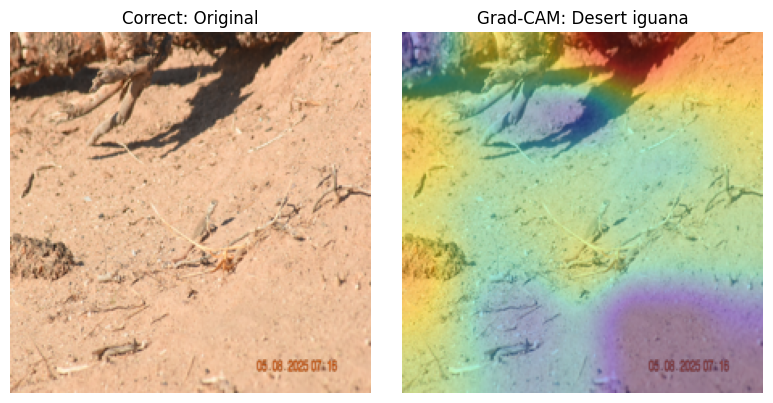

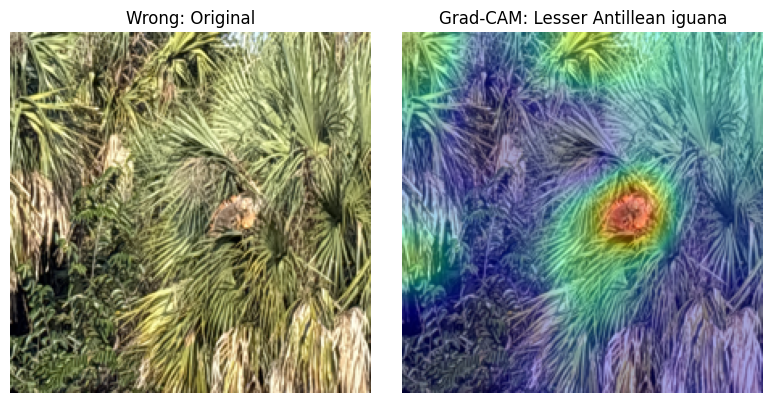

In [34]:
def find_last_conv_layer(model_or_layer):
    for layer in reversed(model_or_layer.layers):
        if isinstance(layer, keras.Model):
            nested = find_last_conv_layer(layer)
            if nested is not None:
                return nested
        if isinstance(layer, layers.Conv2D):
            return layer
    return None


def call_layer(layer, x, training=False):
    try:
        return layer(x, training=training)
    except TypeError:
        return layer(x)


def make_gradcam_heatmap(img_array, model, class_index=None):
    backbone = model.get_layer(BACKBONE_LAYER_NAME)
    last_conv_layer = find_last_conv_layer(backbone)
    if last_conv_layer is None:
        raise ValueError("Could not find a Conv2D layer for Grad-CAM.")

    backbone_feature_model = keras.Model(
        backbone.inputs,
        [last_conv_layer.output, backbone.output],
    )
    backbone_index = model.layers.index(backbone)

    with tf.GradientTape() as tape:
        x = img_array
        for layer in model.layers[1:backbone_index]:
            x = call_layer(layer, x, training=False)

        conv_outputs, x = backbone_feature_model(x, training=False)

        for layer in model.layers[backbone_index + 1:]:
            x = call_layer(layer, x, training=False)

        predictions = x
        if class_index is None:
            class_index = tf.argmax(predictions[0])
        class_channel = predictions[:, class_index]

    grads = tape.gradient(class_channel, conv_outputs)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))
    conv_outputs = conv_outputs[0]
    heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)
    heatmap = tf.maximum(heatmap, 0) / (tf.reduce_max(heatmap) + 1e-8)
    return heatmap.numpy(), predictions.numpy()


def load_image_for_model(path):
    image = decode_and_resize(tf.constant(str(path)))
    return tf.expand_dims(image, axis=0)


def show_gradcam(path, model, title_prefix="", alpha=0.35):
    img_array = load_image_for_model(path)
    heatmap, predictions = make_gradcam_heatmap(img_array, model)
    pred_idx = int(predictions[0].argmax())

    original = Image.open(path).convert("RGB").resize(IMG_SIZE)
    heatmap_resized = Image.fromarray(np.uint8(255 * heatmap)).resize(IMG_SIZE)
    heatmap_colored = plt.cm.jet(np.array(heatmap_resized) / 255.0)[:, :, :3]
    overlay = np.uint8((1 - alpha) * np.array(original) + alpha * 255 * heatmap_colored)

    fig, axes = plt.subplots(1, 2, figsize=(8, 4))
    axes[0].imshow(original)
    axes[0].set_title(f"{title_prefix}Original")
    axes[0].axis("off")

    axes[1].imshow(overlay)
    axes[1].set_title(f"Grad-CAM: {id_to_class[pred_idx].replace('_', ' ')}")
    axes[1].axis("off")
    plt.tight_layout()
    plt.show()


correct_df = final_results_df[final_results_df["label"] == final_results_df["pred_label"]]
if not correct_df.empty:
    correct_path = correct_df.sort_values("confidence", ascending=False).iloc[0]["filepath"]
    show_gradcam(correct_path, final_model, title_prefix="Correct: ")

wrong_df = final_results_df[final_results_df["label"] != final_results_df["pred_label"]]
if not wrong_df.empty:
    wrong_path = wrong_df.sort_values("confidence", ascending=False).iloc[0]["filepath"]
    show_gradcam(wrong_path, final_model, title_prefix="Wrong: ")

## 16. Conclusion

Summarize the final project findings here:

- EDA findings: class balance, image sizes, suspicious samples, and duplicate patterns.
- Cleaning decisions: corrupt/unreadable files and same-class exact/near duplicates were quarantined; odd-size images were kept because resizing handles size differences.
- Model results: compare baseline and final tuned model metrics.
- Problems encountered: duplicate leakage risk, possible label noise, and visually similar species.
- What helped: transfer learning, realistic augmentation, duplicate cleaning, callbacks, and Optuna tuning.
- Limitations: small dataset size, possible remaining label noise, and holdout validation rather than a full cross-validation protocol.

## 17. GenAI Usage Paragraph

Generative AI was used as a coding and documentation assistant during this project. It helped structure the notebook, suggest a professional deep learning workflow, write reusable TensorFlow/Keras helper functions, and formulate explanations for EDA, cleaning, model training, evaluation, tuning, Cleanlab, and Grad-CAM. All generated code and text were reviewed, adapted, and tested by the project team. Dataset decisions, interpretation of visual findings, cleaning choices, and final conclusions remain the responsibility of the authors.